In [1]:
import pandas as pd 
import numpy as np 
import seaborn as sns 
import matplotlib.pyplot as plt 
import scipy.stats
import os
from adjustText import adjust_text
import matplotlib.patheffects as PathEffects
import warnings
warnings.filterwarnings('ignore')
plt.rc('font', family='Helvetica')

In [29]:
sample_key = pd.read_excel('../../screening_data/sample_key.xlsx')

#exclude CDK12/13 for now
sample_key = sample_key[sample_key['Screen_data_location']!='CDK12_13']

class_holder = []

for i, val in sample_key.iterrows():
    sample = val['Sample']
    file_name = val['File_Name']
    editor = val['Editor']
    data_loc = val['Screen_data_location']
    subpool = val['Subpool']

    #get the directory and the relevant files
    j = os.listdir(f'../../screening_data/{data_loc}_screen_data/classification')
    file_list = [i for i in j if file_name in i]

    #extract and combine files (data split by sequencer for same sample)
    a = pd.read_csv(f'../../screening_data/{data_loc}_screen_data/classification/{file_list[0]}')
    b = pd.read_csv(f'../../screening_data/{data_loc}_screen_data/classification/{file_list[1]}')
    a['count'] = a['count']+b['count']

    a['percentage'] = 100*np.asarray(a['count'])/(a.loc[a['classification']=='good quality', 'count'].values[0])

    a['Sample'] = sample
    a['Editor'] = editor
    a['Subpool'] = subpool
    a['Data_loc'] = data_loc

    class_holder.append(a)

comb_class = pd.concat(class_holder)

In [35]:
sequencing_sets = ['ABE_subpool_1', 'CBE_subpool_1', 'SY_5609', 'KB_compound_mut']

pool1 = comb_class[comb_class['Data_loc'].isin(['ABE_subpool_1', 'CBE_subpool_1'])]
SY = comb_class[comb_class['Data_loc']=='SY_5609']
compound = comb_class[comb_class['Data_loc']=='KB_compound_mut']

In [42]:
comb_class

,classification,count,percentage,Sample,Editor,Subpool,Data_loc
0,good quality,36280648.0,100.000000,Plasmid,PLASMID,1,CBE_subpool_1
1,low_qual_r1,633841.0,1.747050,Plasmid,PLASMID,1,CBE_subpool_1
2,low_qual_r2,960770.0,2.648161,Plasmid,PLASMID,1,CBE_subpool_1
3,low_qual_r12,640102.0,1.764307,Plasmid,PLASMID,1,CBE_subpool_1
4,no_match_bc,773192.0,2.131142,Plasmid,PLASMID,1,CBE_subpool_1
...,...,...,...,...,...,...,...
5,bc_identified,39259412.0,50.438095,KB_4000_REP3,CBE,1,KB_compound_mut
6,proto_identified_perfect,14560115.0,18.705946,KB_4000_REP3,CBE,1,KB_compound_mut
7,proto_identified_imperfect,3760353.0,4.831072,KB_4000_REP3,CBE,1,KB_compound_mut
8,proto_identified_recombined,18702202.0,24.027447,KB_4000_REP3,CBE,1,KB_compound_mut


Text(0.5, 0, 'Recombination %')

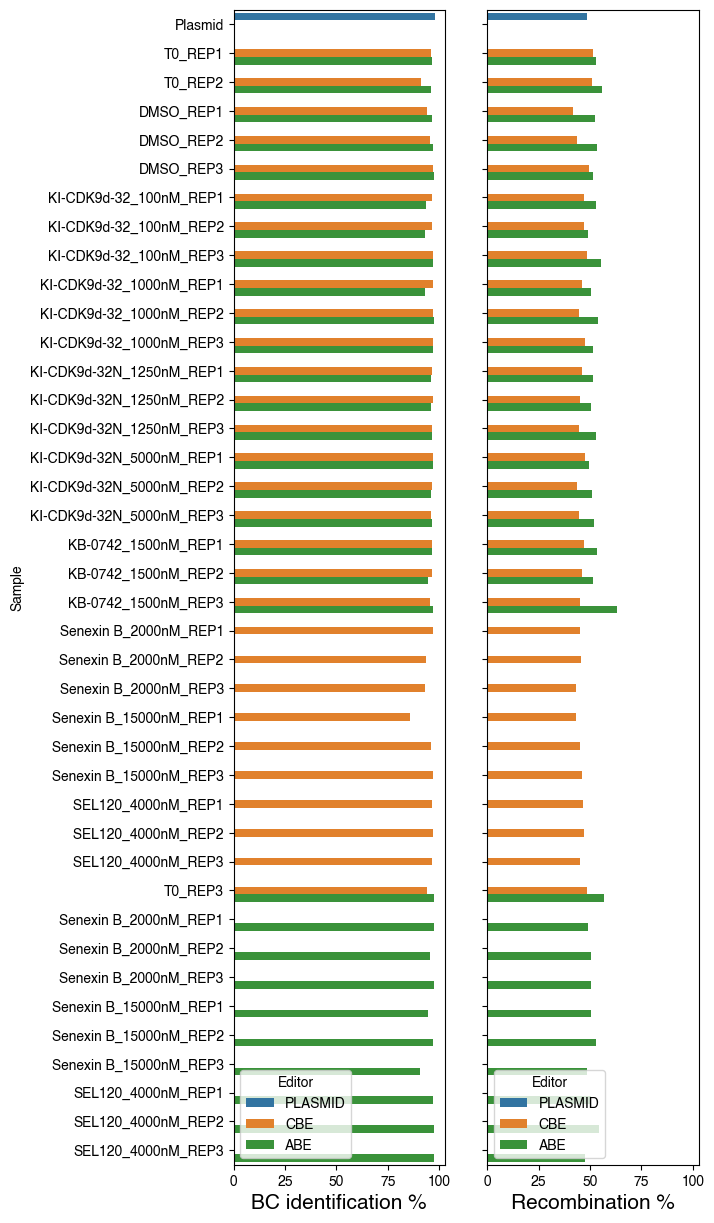

In [46]:
fig, ax = plt.subplots(1,2,figsize=(6,15), sharey=True, sharex=True)
g = sns.barplot(data=pool1[pool1['classification']=='bc_identified'], y='Sample', x='percentage', hue='Editor', ax=ax[0])
h = sns.barplot(data=pool1[pool1['classification']=='proto_identified_recombined'], y='Sample', x='percentage', hue='Editor', ax=ax[1])

ax[0].set_xlabel('BC identification %', fontsize=15)
ax[1].set_xlabel('Recombination %', fontsize=15)

Text(0.5, 0, 'Recombination %')

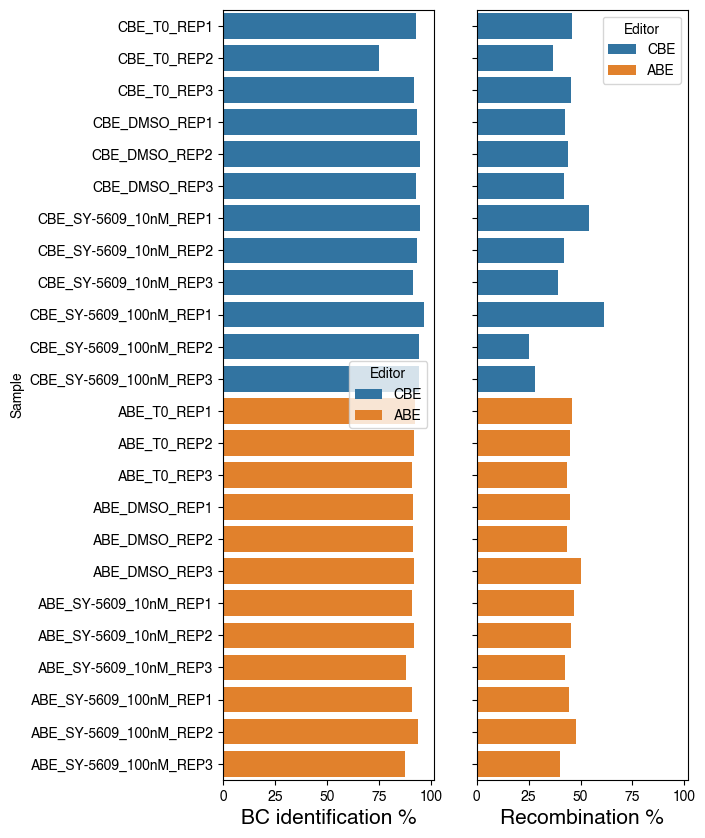

In [49]:
fig, ax = plt.subplots(1,2,figsize=(6,10), sharey=True, sharex=True)
g = sns.barplot(data=SY[SY['classification']=='bc_identified'], y='Sample', x='percentage', hue='Editor', ax=ax[0])
h = sns.barplot(data=SY[SY['classification']=='proto_identified_recombined'], y='Sample', x='percentage', hue='Editor', ax=ax[1])

ax[0].set_xlabel('BC identification %', fontsize=15)
ax[1].set_xlabel('Recombination %', fontsize=15)

Text(0.5, 0, 'Recombination %')

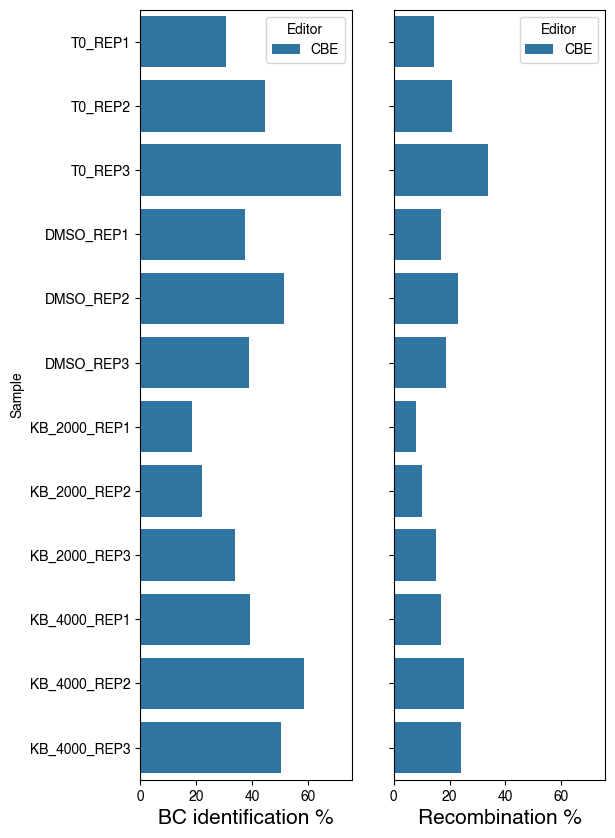

In [50]:
fig, ax = plt.subplots(1,2,figsize=(6,10), sharey=True, sharex=True)
g = sns.barplot(data=compound[compound['classification']=='bc_identified'], y='Sample', x='percentage', hue='Editor', ax=ax[0])
h = sns.barplot(data=compound[compound['classification']=='proto_identified_recombined'], y='Sample', x='percentage', hue='Editor', ax=ax[1])

ax[0].set_xlabel('BC identification %', fontsize=15)
ax[1].set_xlabel('Recombination %', fontsize=15)